# Stable Diffusion XL (SDXL)

O modelo stable diffusion mais atual é o SDXL. Este modelo precisa de bastante memória de GPU!

Criação do modelo

In [ ]:
import torch
from diffusers import DiffusionPipeline

base = DiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0", torch_dtype=torch.float16, 
    variant="fp16", use_safetensors=True) #.to("cuda")
base.enable_model_cpu_offload()

refiner = DiffusionPipeline.from_pretrained("stabilityai/stable-diffusion-xl-refiner-1.0",
    text_encoder_2=base.text_encoder_2, vae=base.vae, torch_dtype=torch.float16,
    use_safetensors=True, variant="fp16")  #.to("cuda")
refiner.enable_model_cpu_offload()

Geração da imagem

In [ ]:
generator = torch.Generator(device="cpu").manual_seed(0)

prompt = "A majestic lion jumping from a big stone at night"

image = base(
    prompt=prompt,
    num_inference_steps=40,
    denoising_end=0.8,
    output_type="latent", generator=generator
).images
image = refiner(
    prompt=prompt,
    num_inference_steps=40,
    denoising_start=0.8,
    image=image, generator=generator
).images[0]

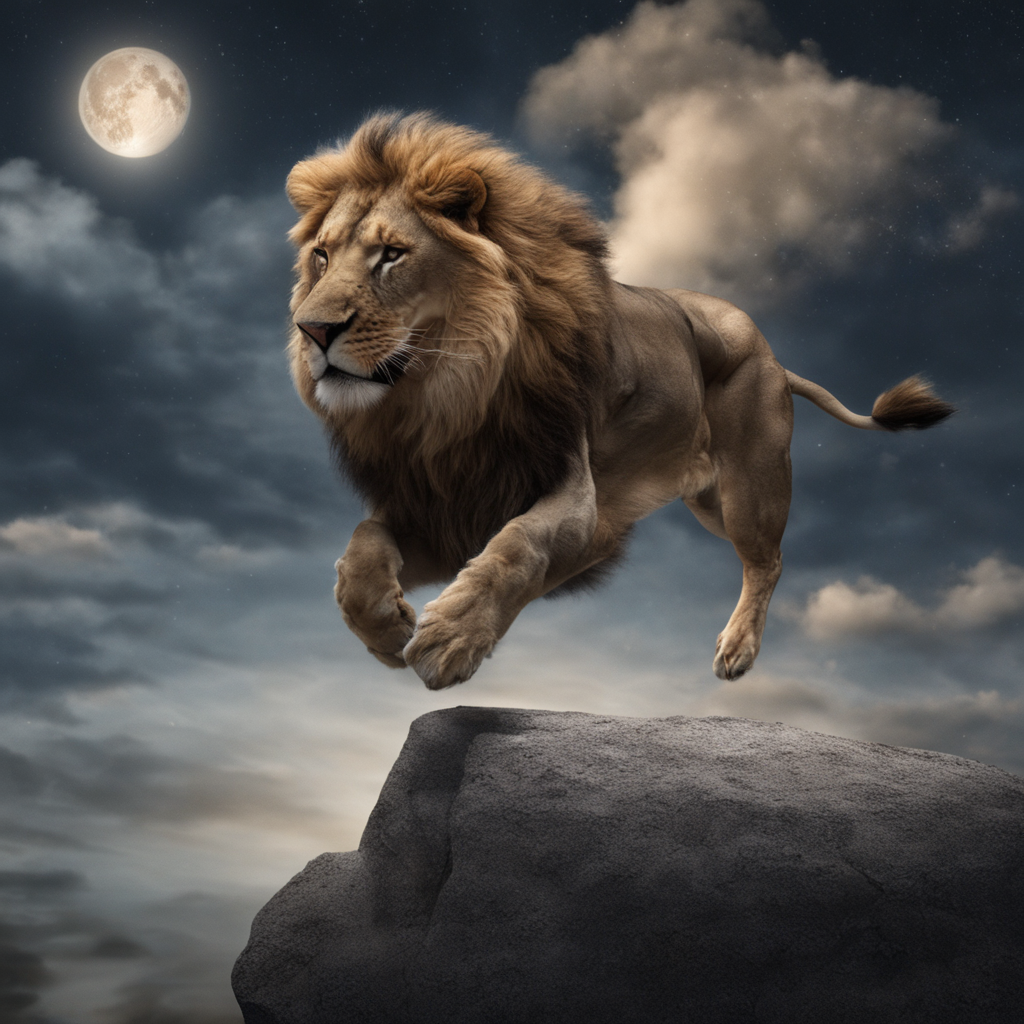

In [3]:
image

In [ ]:
from diffusers import AutoPipelineForImage2Image

refiner_i2i = AutoPipelineForImage2Image.from_pipe(refiner)
refiner_i2i.enable_model_cpu_offload()

generator = torch.Generator(device="cpu").manual_seed(0)
prompt = "An amazing view on top of a mountain"

image = base(
    prompt=prompt,
    num_inference_steps=40,
    generator=generator
).images[0]

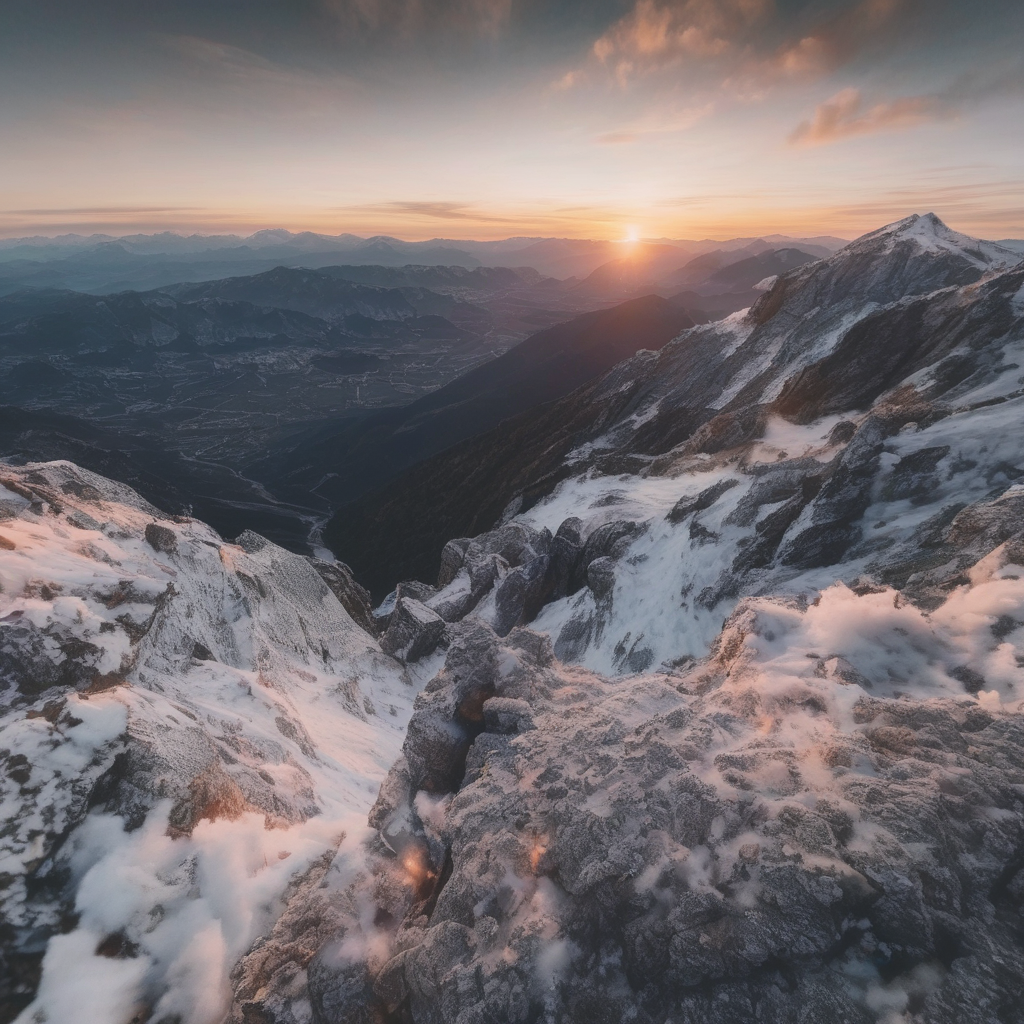

In [5]:
image

In [ ]:
generator = torch.Generator(device="cpu").manual_seed(0)
prompt = "A house is on top of the mountain"

image_ref = refiner_i2i(
    prompt=prompt,
    image=image,
    num_inference_steps=40,
    strength=0.7,   # quanto de ruído adicionar para gerar a nova imagem
    generator=generator
).images[0]

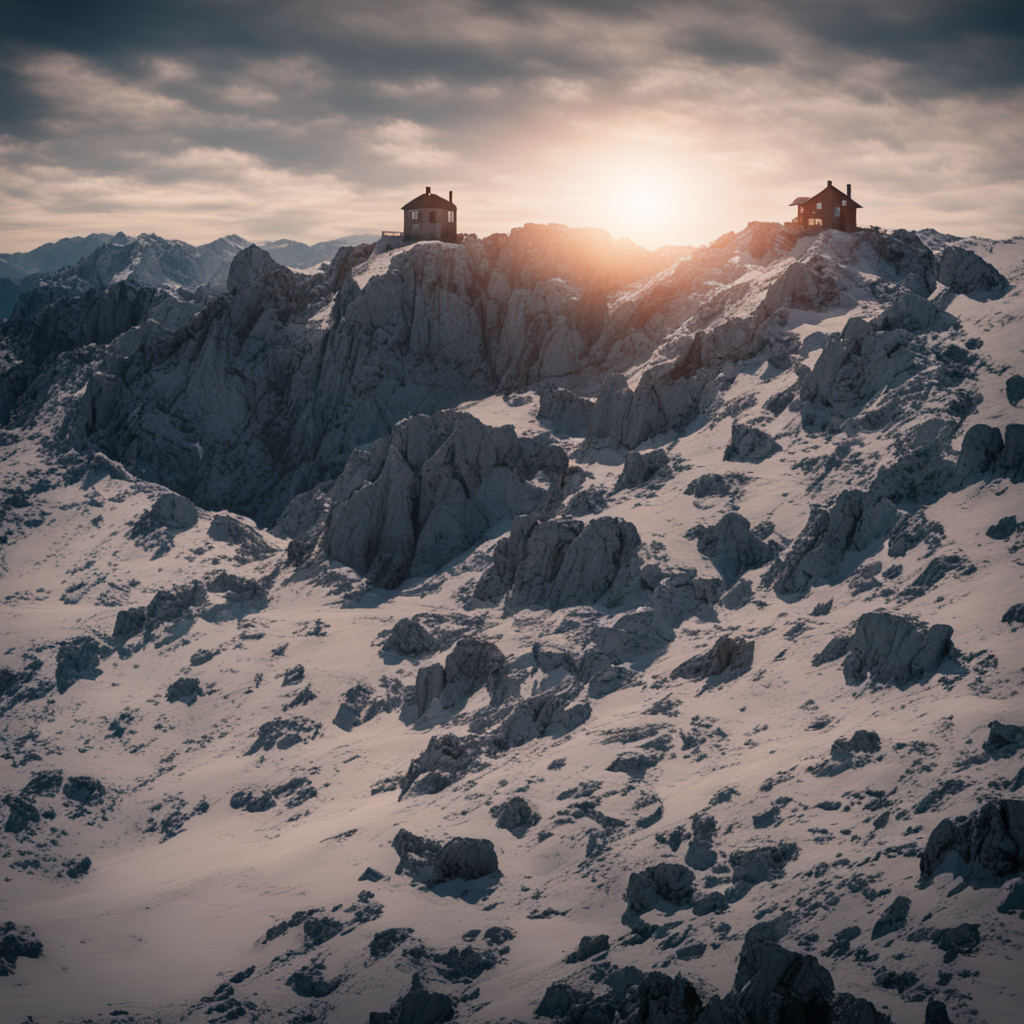

In [7]:
image_ref

### Para saber mais

A documentação da biblioteca diffusers possui diversos exemplos sobre o uso de modelos de difusão. No link

https://huggingface.co/docs/diffusers/quicktour#diffusionpipeline

há uma tabela com as principais tarefas de geração de imagens que podem ser realizadas com a biblioteca: geração incondicional, geração condicionada em texto, geração condicionada em outra imagem e inpainting (remoção de objetos ou artefatos de imagens). 

Por exemplo, há [instruções para geração de imagens a partir de texto](https://huggingface.co/docs/diffusers/using-diffusers/conditional_image_generation) e também [exemplos de geração usando o modelo SDXL](https://huggingface.co/docs/diffusers/using-diffusers/sdxl)

A biblioteca também possui uma documentação sobre procedimentos que podem ser utilizados para refinar um modelo em imagens específicas. Por exemplo, a técnica [textual inversion](https://huggingface.co/docs/diffusers/training/text_inversion) permite refinar um modelo de geração em cerca de 5 imagens de um objeto específico e gerar novas imagens com esse objeto.


